In [1]:
import pandas as pd
import numpy as np


In [2]:
courses = pd.read_csv('/content/courses.csv')#coures and its id
students = pd.read_csv('/content/students.csv')#students detail
nov = pd.read_csv('/content/reg-month1.csv')# no of people in the nov
dec = pd.read_csv('/content/reg-month2.csv')#no of people in the dec
matches = pd.read_csv('/content/matches.csv')
delivery = pd.read_csv('/content/deliveries.csv')

In [3]:
nov.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [4]:
# pd.concat
# ignore_index
# df.append
# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [5]:
# concate
#use to stack vertically
reg=pd.concat([nov,dec],ignore_index=True)
reg.head(3)

,student_id,course_id
0,23,1
1,15,5
2,18,6


In [6]:
multi=pd.concat([nov,dec],keys=['Nov','Dec'])
#Multiindex Concate
multi.loc[('Dec',4)]
multi.loc[('Nov',5)]
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [7]:
#horizontal concation
hori=pd.concat([nov,dec],axis=1)
hori.head(5)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9


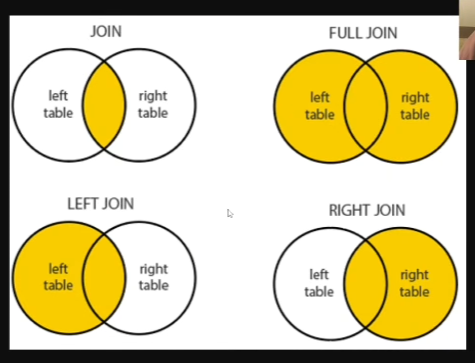

In [8]:
#inner join (****INTERVEIW****)(join)
# It is use to join the common info between two tables
#inner=pd.concat([reg,students],axis=1,join='inner')
inner=students.merge(reg,how='inner',on='student_id')
inner.shape
inner.head(5)

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5


In [9]:
#left join
left=courses.merge(reg,how='left',on='course_id')
left.sample(5)

,course_id,course_name,price,student_id
40,8,pandas,1099,18.0
1,1,python,2499,18.0
17,4,machine learning,9999,19.0
52,10,pyspark,2499,11.0
30,6,power bi,1899,14.0


In [10]:
#right join
right=courses.merge(reg,how='right',on='course_id')
right.sample(5)

,course_id,course_name,price,student_id
24,3,data analysis,4999,3
11,6,power bi,1899,1
41,5,tableau,2499,2
16,1,python,2499,21
21,1,python,2499,25


In [11]:
#outer join
outer=courses.merge(reg,how='outer',on='course_id')
outer.sample(5)

,course_id,course_name,price,student_id
7,1,python,2499,14.0
25,5,tableau,2499,22.0
44,9,plotly,699,1.0
47,10,pyspark,2499,7.0
21,5,tableau,2499,16.0


In [12]:
#find the total revenue generated
rev=reg.merge(courses,how='inner',on='course_id')
rev['price'].sum()

np.int64(154247)

In [13]:
#find mounth by mounth revenue
temp_df=pd.concat([nov,dec],keys=['Nov','Dec']).reset_index()
temp_df.merge(courses,on='course_id').groupby('level_0')['price'].sum()

,price
level_0,
Dec,65072
Nov,89175


In [14]:
#Print the registration Table
#cols->name->course->price
reg.merge(students,on="student_id").merge(courses,on="course_id")[['name','course_name','price']]


,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

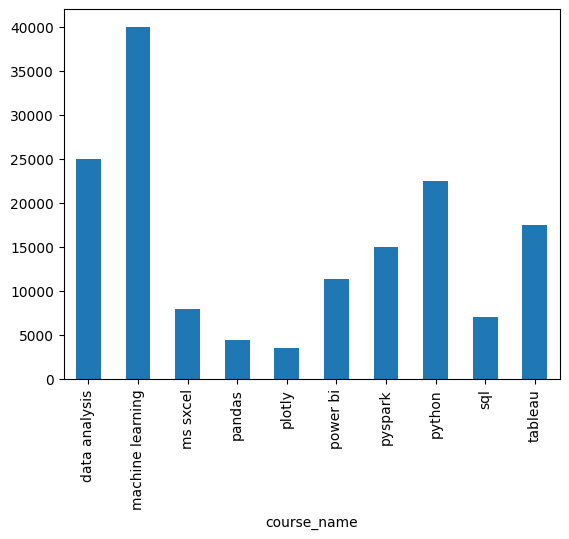

In [15]:
#Plot a bar chart of revenue/course
reg.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [21]:
#find the student enrolled in both mounths
common_st_id=np.intersect1d(nov['student_id'],dec['student_id'])
students[students['student_id'].isin(common_st_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [22]:
#find the course which got no enrollment
students[students['student_id'].isin(np.setdiff1d(courses['course_id'],reg['course_id']))]

,student_id,name,partner
10,11,David Mukhopadhyay,20
11,12,Radha Dutt,19


In [28]:
#print the student name -> patnername for all enrolled student
#self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [32]:
#Find the top 3 students who did most no. of enrollment
reg.groupby('student_id')['course_id'].count().reset_index().sort_values('course_id',ascending=False).head(3)

,student_id,course_id
15,23,6
3,7,5
0,1,4


In [33]:
#alternate syntax to merge
reg.groupby('student_id').agg({'course_id':'count'}).reset_index().sort_values('course_id',ascending=False).head(3)


,student_id,course_id
15,23,6
3,7,5
0,1,4


In [44]:
matches.head(3)

(3, 18)

In [48]:
delivery

,id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122819,518,1,Mumbai Indians,Kolkata Knight Riders,18,5,CJ Anderson,RG Sharma,Shakib Al Hasan,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
122820,518,1,Mumbai Indians,Kolkata Knight Riders,18,6,CJ Anderson,RG Sharma,Shakib Al Hasan,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
122821,518,1,Mumbai Indians,Kolkata Knight Riders,18,7,CJ Anderson,RG Sharma,Shakib Al Hasan,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN
122822,518,1,Mumbai Indians,Kolkata Knight Riders,19,1,CJ Anderson,RG Sharma,AD Russell,0.0,...,0.0,0.0,0.0,0.0,6.0,0.0,6.0,NaN,NaN,NaN


In [40]:
delivery.rename(columns={"match_id": "id"}, inplace=True)

In [53]:
#IPL Problem
#find the 3 studium with sixes per match
num_matches=matches['venue'].value_counts()
num_matches.head(3)
temp_df=delivery.merge(matches,on='id')
six_df=temp_df[temp_df['batsman_runs']==6]
std_df=six_df.groupby('venue')['batsman_runs'].count()/num_matches
std_df.sort_values(ascending=False).head(3)


,0
venue,
Holkar Cricket Stadium,17.600000
Sharjah Cricket Stadium,12.666667
Himachal Pradesh Cricket Association Stadium,12.000000


In [63]:
#find the orange cap holder of each season
temp_df
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616.0
229,2009,ML Hayden,572.0
446,2010,SR Tendulkar,618.0
502,2011,CH Gayle,608.0
684,2012,CH Gayle,733.0
910,2013,MEK Hussey,733.0
1088,2014,RV Uthappa,660.0
1127,2015,RG Sharma,86.0
1162,2017,DA Warner,641.0
